# Customer Support SLA and Backlog

**Author: Tajamul Khan**

Where is the support queue missing service commitments?

Original synthetic teaching data. All outputs below are calculated by executing these cells. This is an analytical portfolio case study, not a real client engagement.

## Situation and task

A support manager needs to separate first-response delays from unresolved ticket backlog.

Measure response SLA compliance by priority and aging of open tickets at a fixed snapshot.

## Data contract and KPI definitions

One row per ticket created in December. Snapshot 2026-01-01. First-response targets: High 4h, Medium 12h, Low 24h. Pending unresponded tickets still within target are excluded from the SLA denominator; overdue unresponded tickets count as misses. CSAT coverage denominator is closed tickets.

See `data/README.md` for field types, source and seed.

In [1]:
from pathlib import Path
import json, sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
BASE = Path.cwd()
assert (BASE/'data/raw.csv').exists(), 'Run from this project directory'
OUT = BASE/'outputs'
OUT.mkdir(exist_ok=True)
pd.set_option('display.max_columns', 20)
plt.rcParams.update({'figure.dpi':120, 'axes.spines.top':False, 'axes.spines.right':False})
df = pd.read_csv(BASE/'data/raw.csv')
if 'date' in df:
    df['date'] = pd.to_datetime(df['date'])
print('Raw shape:',df.shape)
display(df.head())


Raw shape: (3500, 6)


,ticket_id,date,priority,first_response_hours,resolution_hours,csat
0,1,2025-12-31 06:00:00,Low,13.35,NaN,NaN
1,2,2025-12-18 11:00:00,Medium,2.57,41.401967,NaN
2,3,2025-12-09 02:00:00,Medium,18.80,55.813242,NaN
3,4,2025-12-10 10:00:00,High,16.47,63.458027,NaN
4,5,2025-12-17 18:00:00,Medium,11.83,151.202264,NaN


## Validate the source

Inspect missingness and grain before computing metrics. Missing outcomes are not automatically zeros.

In [2]:
audit=pd.DataFrame({'dtype':df.dtypes.astype(str),'missing':df.isna().sum(),'unique_values':df.nunique()})
display(audit)
print('Exact duplicate rows:',df.duplicated().sum())
audit.to_csv(OUT/'data_quality.csv')


Exact duplicate rows: 0


,dtype,missing,unique_values
ticket_id,int64,0,3500
date,datetime64[ns],0,731
priority,object,0,3
first_response_hours,float64,47,1750
resolution_hours,float64,401,3099
csat,float64,1777,5


## Action: analysis

Apply priority-specific thresholds, retain unresolved tickets in backlog and report satisfaction response coverage.

In [3]:
assert df.ticket_id.is_unique
snapshot=pd.Timestamp('2026-01-01');df['age_hours']=(snapshot-df.date).dt.total_seconds()/3600
df['sla_hours']=df.priority.map({'High':4,'Medium':12,'Low':24})
df['sla_eligible']=df.first_response_hours.notna()|(df.age_hours>df.sla_hours)
df['sla_met']=(df.first_response_hours<=df.sla_hours).astype(int)
df['open_ticket']=df.resolution_hours.isna().astype(int)
summary=df.groupby('priority').agg(tickets=('ticket_id','size'),eligible=('sla_eligible','sum'),met=('sla_met','sum'),open_tickets=('open_ticket','sum'))
summary['sla_pct']=100*summary.met/summary.eligible
metrics={'Eligible response SLA met (%)':100*df.sla_met.sum()/df.sla_eligible.sum(),'Open tickets':df.open_ticket.sum(),'CSAT response coverage of closed (%)':100*df.csat.notna().sum()/df.resolution_hours.notna().sum()}
chart=summary.sla_pct; ylabel='Eligible response SLA met (%)'
df[df.open_ticket==1].to_csv(OUT/'open_ticket_aging.csv',index=False)

## Deep dive: Backlog age and satisfaction coverage

Retain unresolved tickets in backlog. Closed-ticket resolution averages alone omit the slowest cases still in progress.

High has the lowest eligible first-response SLA compliance (34.43%). Investigate triage and staffing while retaining overdue unanswered tickets in the metric.
Out[4]: 159


,open_tickets,mean_age_hours
age_band,,
0-24h,101,11.47
24-72h,149,46.50
72-168h,125,110.93
168h+,26,235.50


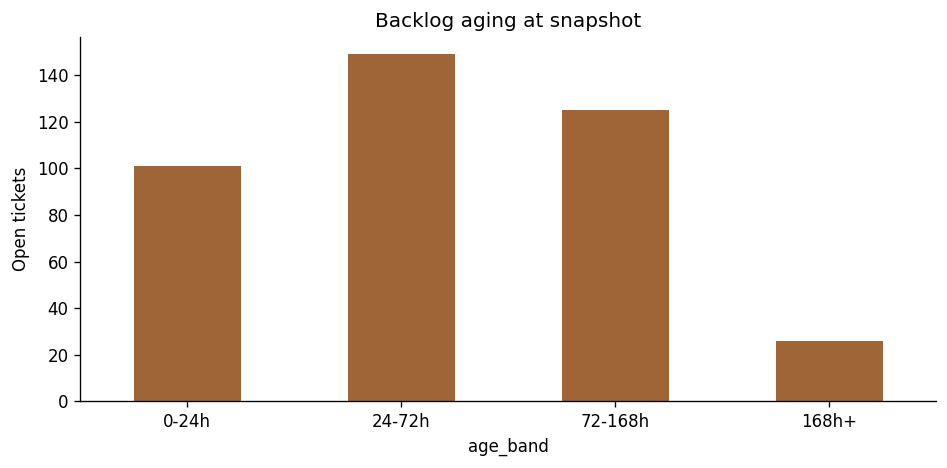

In [4]:

open_df=df[df.open_ticket==1].copy();open_df['age_band']=pd.cut(open_df.age_hours,bins=[0,24,72,168,np.inf],labels=['0-24h','24-72h','72-168h','168h+'],include_lowest=True)
detail=open_df.groupby('age_band',observed=False).agg(open_tickets=('ticket_id','size'),mean_age_hours=('age_hours','mean'))
assert detail.open_tickets.sum()==df.open_ticket.sum()
display(detail.round(2))
fig,ax=plt.subplots(figsize=(8,4));detail.open_tickets.plot.bar(ax=ax,color='#a06536',rot=0);ax.set_ylabel('Open tickets');ax.set_title('Backlog aging at snapshot');fig.tight_layout();fig.savefig(OUT/'detail.png');plt.show()
worst=summary.sla_pct.idxmin()
recommendation=f'{worst} has the lowest eligible first-response SLA compliance ({summary.loc[worst,"sla_pct"]:.2f}%). Investigate triage and staffing while retaining overdue unanswered tickets in the metric.'

detail.to_csv(OUT/'detail.csv')
print(recommendation)
(OUT/'recommendation.txt').write_text(recommendation+'\n')


## Results: calculated evidence

These describe only the included synthetic dataset. They do not measure deployed impact.

In [5]:
display(summary.round(4))
display(pd.Series(metrics,name='value').to_frame())
summary.to_csv(OUT/'summary.csv')
(OUT/'metrics.json').write_text(json.dumps({k:float(v) for k,v in metrics.items()},indent=2))
df.to_csv(OUT/'analysis_ready.csv',index=False)
assert all(np.isfinite(float(v)) for v in metrics.values()), 'Invalid KPI'


,tickets,eligible,met,open_tickets,sla_pct
priority,,,,,
High,703,700,241,87,34.4286
Low,1024,1008,935,124,92.7579
Medium,1773,1755,1278,190,72.8205


,value
Eligible response SLA met (%),70.863413
Open tickets,401.000000
CSAT response coverage of closed (%),55.598580


## SQL cross-check

Load validated facts into SQLite and reconcile shared aggregates against Python.

In [6]:
with sqlite3.connect(':memory:') as conn:
    df.to_sql('facts',conn,index=False,if_exists='replace')
    sql_result=pd.read_sql_query((BASE/'analysis.sql').read_text(),conn)
display(sql_result)
sql_result.to_csv(OUT/'sql_results.csv',index=False)
# Reconcile at least one common aggregate by group, rather than trusting the SQL output.
key=sql_result.columns[0]
py=summary.reset_index()
common=[c for c in sql_result.columns[1:] if c in py.columns]
assert common, 'No comparable aggregate'
joined=sql_result.merge(py,on=key,suffixes=('_sql','_python'),validate='one_to_one')
assert len(joined)==len(summary)==len(sql_result)
for col in common:
    assert np.allclose(joined[col+'_sql'],joined[col+'_python'],rtol=1e-8,atol=1e-6), col
print('SQL / Python reconciliation passed:',common)


SQL / Python reconciliation passed: ['eligible', 'met', 'open_tickets']


,priority,eligible,met,open_tickets
0,High,700,241,87
1,Low,1008,935,124
2,Medium,1755,1278,190


## Visual interpretation

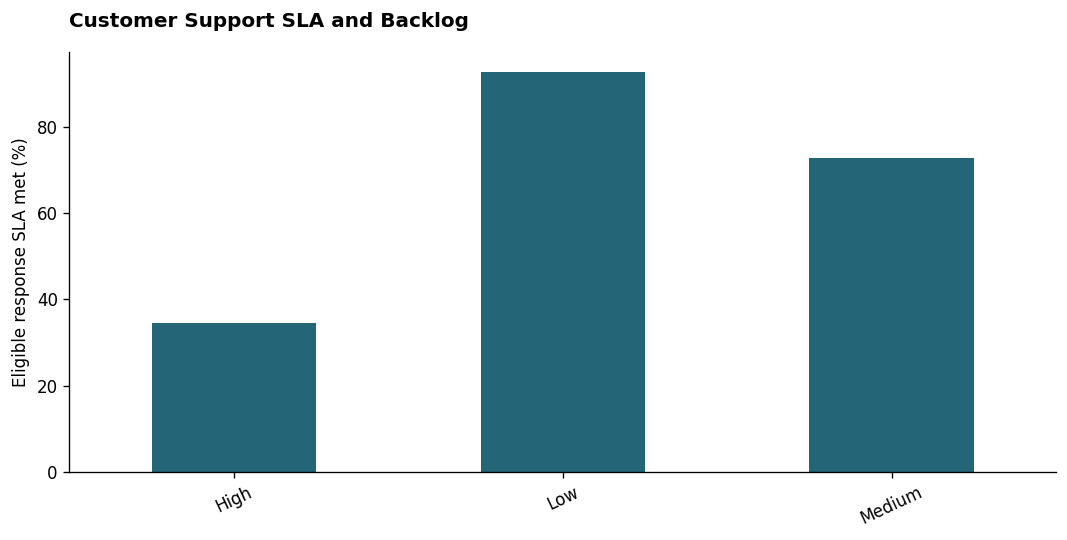

In [7]:
fig,ax=plt.subplots(figsize=(9,4.6))
chart.plot(kind='bar',ax=ax,color='#246577',rot=25)
ax.set_ylabel(ylabel)
ax.set_xlabel('')
ax.set_title('Customer Support SLA and Backlog',loc='left',fontweight='bold',pad=15)
fig.tight_layout()
fig.savefig(OUT/'overview.png',bbox_inches='tight')
plt.show()


## Offline dashboard

The KPI cards and chart are a fixed analysis snapshot. The row filter searches the summary table; it does not recompute the KPIs.

In [8]:
# Standalone dashboard: no remote JavaScript, server or account required.
import html, base64
cards=''.join('<article><span>'+html.escape(k)+'</span><strong>'+f'{v:,.4f}'+'</strong></article>' for k,v in metrics.items())
image=base64.b64encode((OUT/'overview.png').read_bytes()).decode()
table=summary.round(4).to_html(classes='data',border=0)
page='''<!doctype html><html lang="en"><meta charset="utf-8"><meta name="viewport" content="width=device-width, initial-scale=1"><title>Customer Support SLA and Backlog</title>
<style>body{font:16px system-ui;margin:0;background:#f3f5f7;color:#172c3b}main{max-width:1100px;margin:auto;padding:36px}header{border-bottom:3px solid #246577;margin-bottom:24px}small{color:#51616c}.cards{display:flex;gap:14px;flex-wrap:wrap}article{background:white;padding:18px;border:1px solid #d7e0e5;flex:1;min-width:175px}strong{display:block;font-size:27px;margin-top:12px}img{max-width:100%;margin-top:24px}table{border-collapse:collapse;background:white;width:100%;font-size:14px}td,th{padding:12px;text-align:right;border-bottom:1px solid #d7e0e5}input{padding:12px;margin:20px 0;width:280px;max-width:90%}.scroll{overflow:auto}footer{margin-top:24px}</style>
<main><header><small>TAJAMUL KHAN · DATA ANALYST PORTFOLIO</small><h1>Customer Support SLA and Backlog</h1><p>Where is the support queue missing service commitments?</p><p><b>Synthetic teaching data · Fictional 2025 case study</b></p></header><section class="cards">'''+cards+'''</section><img alt="Analysis overview chart" src="data:image/png;base64,'''+image+'''"><h2>Explore summary groups</h2><label for="filter">Filter summary rows</label><br><input id="filter" placeholder="Type a group name"><div class="scroll">'''+table+'''</div><p>SLA is measured in elapsed hours, not business hours. Resolution duration applies only to closed tickets and has survivor bias. CSAT is voluntary.</p><footer>Instagram @tajamul.codes · linkedin.com/in/tajamulkhann/</footer></main>
<script>document.getElementById('filter').addEventListener('input',function(){const q=this.value.toLowerCase();document.querySelectorAll('tbody tr').forEach(r=>r.hidden=!r.textContent.toLowerCase().includes(q))});</script></html>'''
detail_image=base64.b64encode((OUT/'detail.png').read_bytes()).decode()
page=page.replace('<h2>Explore summary groups</h2>','<h2>Analyst finding</h2><p>'+html.escape(recommendation)+'</p><img alt="Supporting analysis" src="data:image/png;base64,'+detail_image+'"><h2>Explore summary groups</h2>')
(OUT/'dashboard.html').write_text(page)
print('Saved dashboard.html, overview.png, summary.csv, metrics.json, SQL results and analysis-ready data.')


Saved dashboard.html, overview.png, summary.csv, metrics.json, SQL results and analysis-ready data.


## Decision, limitations and next step

SLA is measured in elapsed hours, not business hours. Resolution duration applies only to closed tickets and has survivor bias. CSAT is voluntary.

**Next step:** Introduce business calendars, censored time-to-resolution analysis and staffing experiments.

Use the result table to identify a priority for investigation. Avoid claiming that the suggested action has already delivered a business improvement.

## Career discussion

Explain the business question, data grain, denominator, validation, strongest finding and one limitation. Use the README STAR story only after reproducing and understanding this project.